In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report

In [6]:
df = pd.read_csv("KDDTrain+.txt", names=column_names)


In [7]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [8]:
df.shape


(125973, 43)

In [9]:
df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty'],
      dtype='str')

In [10]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [11]:
df.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [12]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['label'].value_counts()

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

In [15]:
df['target'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

In [16]:
df[['label', 'target']].head(10)

,label,target
0,normal,0
1,normal,0
2,neptune,1
3,normal,0
4,normal,0
5,neptune,1
6,neptune,1
7,neptune,1
8,neptune,1
9,neptune,1


In [17]:
encoder = LabelEncoder()

df['protocol_type'] = encoder.fit_transform(df['protocol_type'])
df['service'] = encoder.fit_transform(df['service'])
df['flag'] = encoder.fit_transform(df['flag'])

In [18]:
df[['protocol_type', 'service', 'flag']].head(10)

,protocol_type,service,flag
0,1,20,9
1,2,44,9
2,1,49,5
3,1,24,9
4,1,24,9
5,1,49,1
6,1,49,5
7,1,49,5
8,1,51,5
9,1,49,5


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  int64  
 2   service                      125973 non-null  int64  
 3   flag                         125973 non-null  int64  
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [20]:
X = df.drop(['label', 'target', 'difficulty'], axis=1)

y = df['target']

In [21]:
print(X.shape)
print(y.shape)

(125973, 41)
(125973,)


In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [23]:
print(X_scaled.shape)

(125973, 41)


In [25]:
predictions = model.predict(X_scaled)

In [26]:
predictions[:20]

array([ 1, -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1])

In [27]:
predictions=np.where(predictions==1,0,1)

In [28]:
predictions[:20]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [29]:
print(confusion_matrix(y, predictions))

[[59470  7873]
 [41308 17322]]


In [30]:
print(classification_report(y, predictions))

              precision    recall  f1-score   support

           0       0.59      0.88      0.71     67343
           1       0.69      0.30      0.41     58630

    accuracy                           0.61    125973
   macro avg       0.64      0.59      0.56    125973
weighted avg       0.64      0.61      0.57    125973



In [31]:
print("Normal :", sum(predictions == 0))
print("Attack :", sum(predictions == 1))

Normal : 100778
Attack : 25195


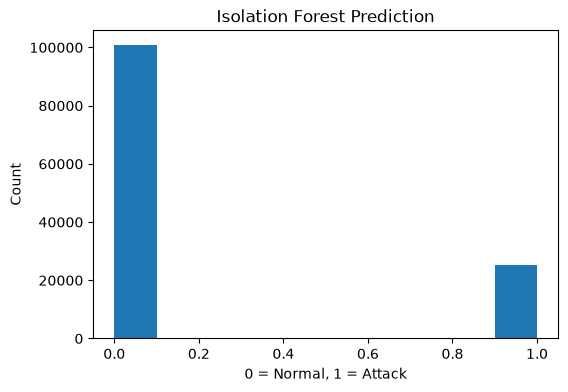

In [32]:
plt.figure(figsize=(6,4))

plt.hist(predictions)

plt.title("Isolation Forest Prediction")

plt.xlabel("0 = Normal, 1 = Attack")

plt.ylabel("Count")

plt.show()

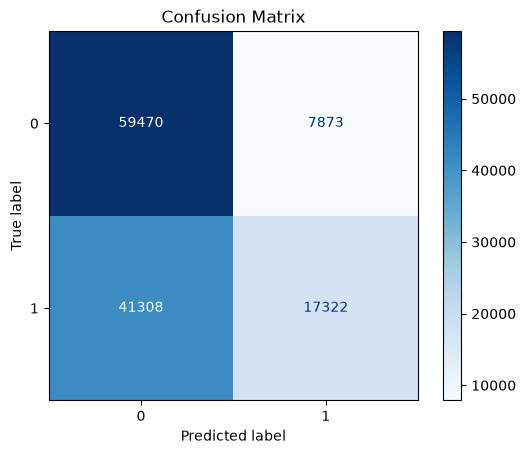

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y,
    predictions,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

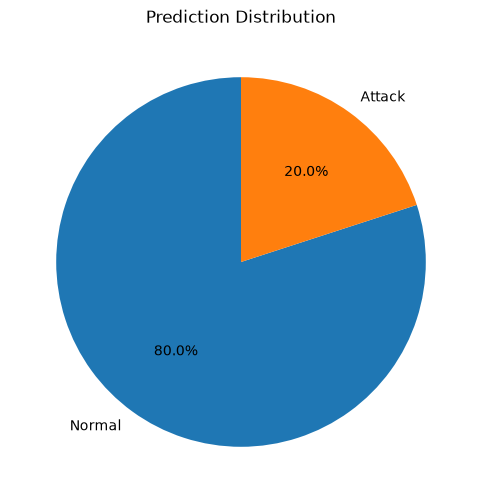

In [34]:
labels = ["Normal", "Attack"]
sizes = [sum(predictions == 0), sum(predictions == 1)]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title("Prediction Distribution")
plt.show()

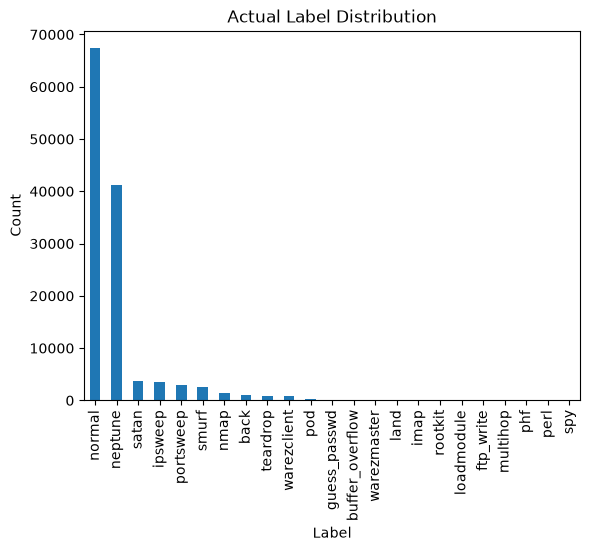

In [36]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.title("Actual Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

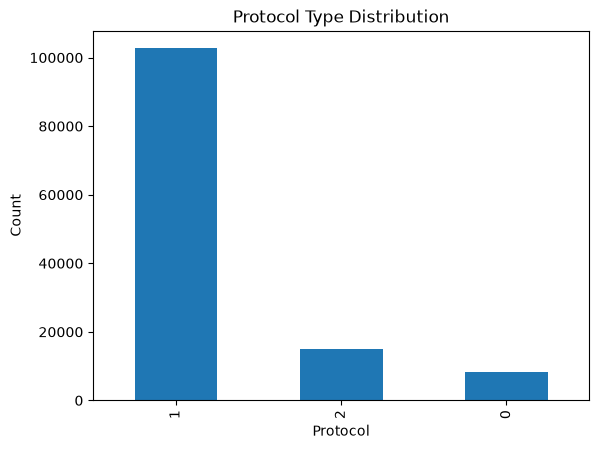

In [37]:
df['protocol_type'].value_counts().plot(kind='bar')

plt.title("Protocol Type Distribution")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.show()

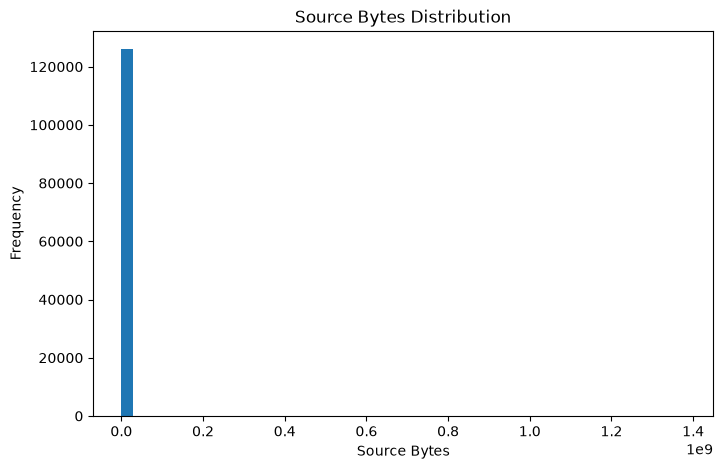

In [38]:
plt.figure(figsize=(8,5))
plt.hist(df['src_bytes'], bins=50)
plt.title("Source Bytes Distribution")
plt.xlabel("Source Bytes")
plt.ylabel("Frequency")
plt.show()

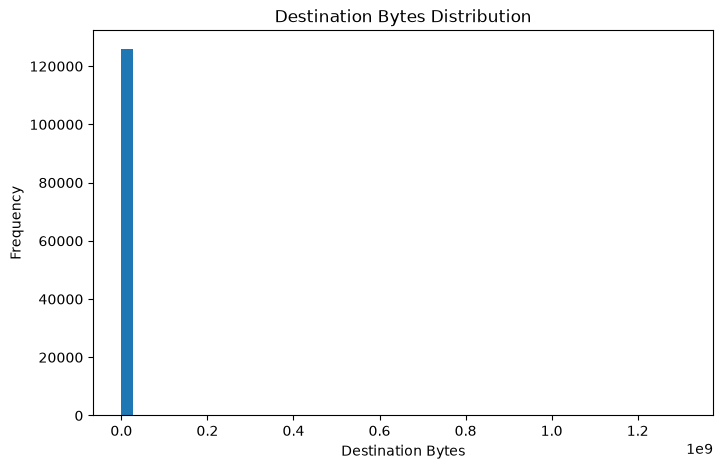

In [39]:
plt.figure(figsize=(8,5))
plt.hist(df['dst_bytes'], bins=50)
plt.title("Destination Bytes Distribution")
plt.xlabel("Destination Bytes")
plt.ylabel("Frequency")
plt.show()

In [40]:
import joblib

joblib.dump(model, "intrusion_detection_model.pkl")

['intrusion_detection_model.pkl']

In [41]:
df['service'].value_counts()

service
24    40338
49    21853
12     9043
54     7313
20     6860
      ...  
61        3
27        2
3         2
22        2
25        1
Name: count, Length: 70, dtype: int64

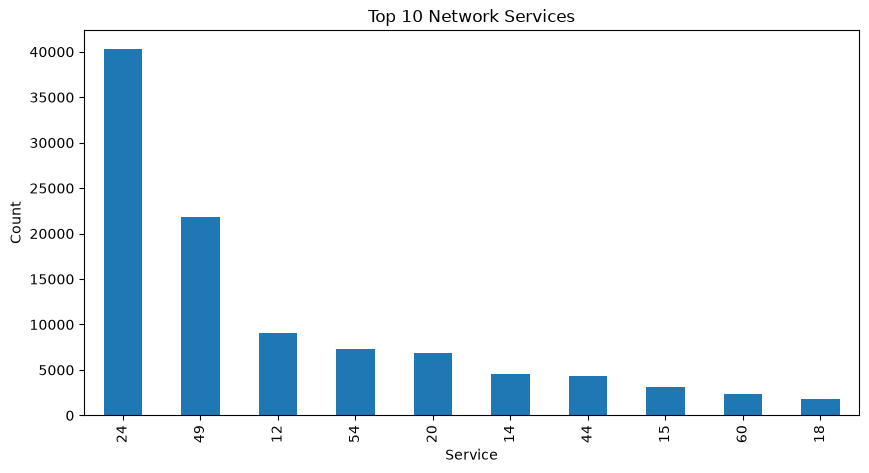

In [42]:
plt.figure(figsize=(10,5))
df['service'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Network Services")
plt.xlabel("Service")
plt.ylabel("Count")
plt.show()

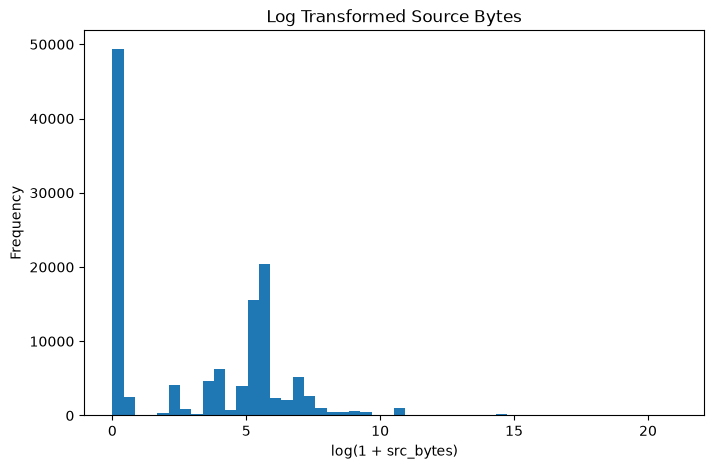

In [43]:
import numpy as np

plt.figure(figsize=(8,5))
plt.hist(np.log1p(df['src_bytes']), bins=50)
plt.title("Log Transformed Source Bytes")
plt.xlabel("log(1 + src_bytes)")
plt.ylabel("Frequency")
plt.show()